# Identificación de eventos extremos
Analizar la relación existente entre precipitaciones extremas (>75 mm) con variables climaticas: Temperatura media anual, velocidad y dirección del viento medio anual, elevación y cobertura. El análisis es realizado con datos del 2022 en ciertas zonas de la región Andina


### Se importan librerias

In [46]:
# Importar librerias
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from pyproj import CRS
import requests
from io import StringIO
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import matplotlib.ticker as mticker #Para que salgan las coordenas como enteras
import numpy as np
import seaborn as sns
import ee
import geemap
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from pointpats import centrography
from matplotlib.patches import Ellipse
import libpysal
from matplotlib.patches import Polygon
from matplotlib.patches import Polygon as MplPolygon, Circle
from shapely.geometry import mapping
from descartes import PolygonPatch
from pointpats import distance_statistics, QStatistic, random, PointPattern
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
from math import exp
from datetime import timedelta
from matplotlib.ticker import MaxNLocator
from scipy.stats import nbinom
import scipy.optimize as opt
from scipy.stats import chisquare
import statsmodels.api as sm
import statsmodels.formula.api as smf
from datetime import datetime

In [2]:
try:
    #ee.Authenticate()
    ee.Initialize(project='my-project-analisis-geoesp')
    print("Google Earth Engine inicializado correctamente.")
except Exception as e:
    print(f"Error al inicializar Earth Engine: {e}")
    print("Asegúrate de que tus credenciales están configuradas y el project ID es correcto.")
    print("Si no lo has hecho, ejecuta 'earthengine authenticate' en tu terminal.")
    exit() # Salir si la inicialización falla

Google Earth Engine inicializado correctamente.


### Descarga de datos
Se extrajo del IDEAM los datos de precipitación diaría, esta plataforma al no contar con un API, se montó los registros en la página Zenodo. El código descarga los datos de precipitación diaria mediante una API. 

In [3]:

ColumnasInteres = ["CodigoEstacion", "NombreEstacion", "Fecha", "Valor"]

# Crear carpeta de descarga
carpeta_descarga = os.path.join(os.getcwd(), "csv_descargados_estaciones")
os.makedirs(carpeta_descarga, exist_ok=True)

# Lista de Zenodo record IDs
record_ids = ["15514418", "15514388"]  # Puedes poner IDs distintos aquí
lista_df = []

for record_id in record_ids:
    api_url = f"https://zenodo.org/api/records/{record_id}"
    respuesta = requests.get(api_url)

    if respuesta.status_code != 200:
        print(f"Error al obtener metadata del ID {record_id}")
        continue

    data = respuesta.json()

    
    for archivo in data.get("files", []):
        nombre = archivo["key"]
        enlace = archivo["links"]["self"]

        if nombre.endswith(".csv"):
            print(f"Descargando: {nombre} desde {enlace}")
            r = requests.get(enlace)
            if r.status_code == 200:
                ruta_local = os.path.join(carpeta_descarga, nombre)
                with open(ruta_local, "wb") as f:
                    f.write(r.content)

                # Leer el CSV directamente desde el contenido de la respuesta
                df = pd.read_csv(StringIO(r.text))
                columnas_validas = [col for col in ColumnasInteres if col in df.columns]
                df_filtrado = df[columnas_validas].copy()
                lista_df.append(df_filtrado)
            else:
                print(f"Error al descargar {nombre}: {r.status_code}")

# Procesar archivos descargados
if lista_df:
    df_total = pd.concat(lista_df, ignore_index=True)
    df_total["Fecha"] = pd.to_datetime(df_total["Fecha"], errors="coerce")
    df_2022 = df_total[df_total["Fecha"].dt.year == 2022]
    grupos_2022 = dict(tuple(df_2022.groupby("CodigoEstacion")))
    print(f"Archivos descargados en: {carpeta_descarga}")
else:
    print("No se descargaron archivos válidos.")




Descargando: Santander9.csv desde https://zenodo.org/api/records/15514419/files/Santander9.csv/content
Descargando: Santander1.csv desde https://zenodo.org/api/records/15514419/files/Santander1.csv/content
Descargando: Santander8.csv desde https://zenodo.org/api/records/15514419/files/Santander8.csv/content
Descargando: VC5.csv desde https://zenodo.org/api/records/15514419/files/VC5.csv/content
Descargando: VC2.csv desde https://zenodo.org/api/records/15514419/files/VC2.csv/content
Descargando: Tolima6.csv desde https://zenodo.org/api/records/15514419/files/Tolima6.csv/content
Descargando: VC1.csv desde https://zenodo.org/api/records/15514419/files/VC1.csv/content
Descargando: Tolima1.csv desde https://zenodo.org/api/records/15514419/files/Tolima1.csv/content
Descargando: Tolima3.csv desde https://zenodo.org/api/records/15514419/files/Tolima3.csv/content
Descargando: VC4.csv desde https://zenodo.org/api/records/15514419/files/VC4.csv/content
Descargando: NS4.csv desde https://zenodo.or

### Filtrado de los datos
* Se filtra cada archivo para el año 2022
* Se excluyen del análisis las estaciones que carecen de mas del 10% de los datos
* Se guarda en un dt los años en los que hubo eventos con precipitación mayor al umbral
* Se guarda en un dt los años en los que no hubo eventos con precipitación mayor al umbral
* Para estos datos se encontró una relación de ocurrencias vs. no ocurrencias de 1:4



Lluvia total 2022 por estación

    CodigoEstacion  LluviaTotal_2022
0        11070030            4007.0
1        11075020            2285.5
2        11110020            2879.2
3        12010110            3062.4
4        12010170            7693.0


 Estaciones usadas en el análisis 


11070030: 365
11075020: 364
11110020: 360
12010110: 365
12010170: 365
12030010: 365
12030020: 365
16010020: 365
16010110: 365
16020250: 365
16030030: 365
16030080: 365
16030100: 364
16050100: 364
16055010: 365
16055040: 364
21010140: 365
21025030: 350
21030080: 364
21040030: 362
21050250: 365
21050290: 337
21055030: 365
21057060: 330
21060100: 340
21100080: 365
21110180: 356
21110290: 364
21130040: 339
21130110: 364
21130180: 361
21145070: 356
21147050: 362
21160030: 363
21160040: 363
21160050: 365
21160130: 360
21160160: 364
21165010: 362
21170020: 343
21180160: 329
21185080: 362
21190410: 365
21200160: 365
21200620: 358
21201060: 337
21202160: 365
21205660: 330
21205920: 364
21205940: 365
21205980: 

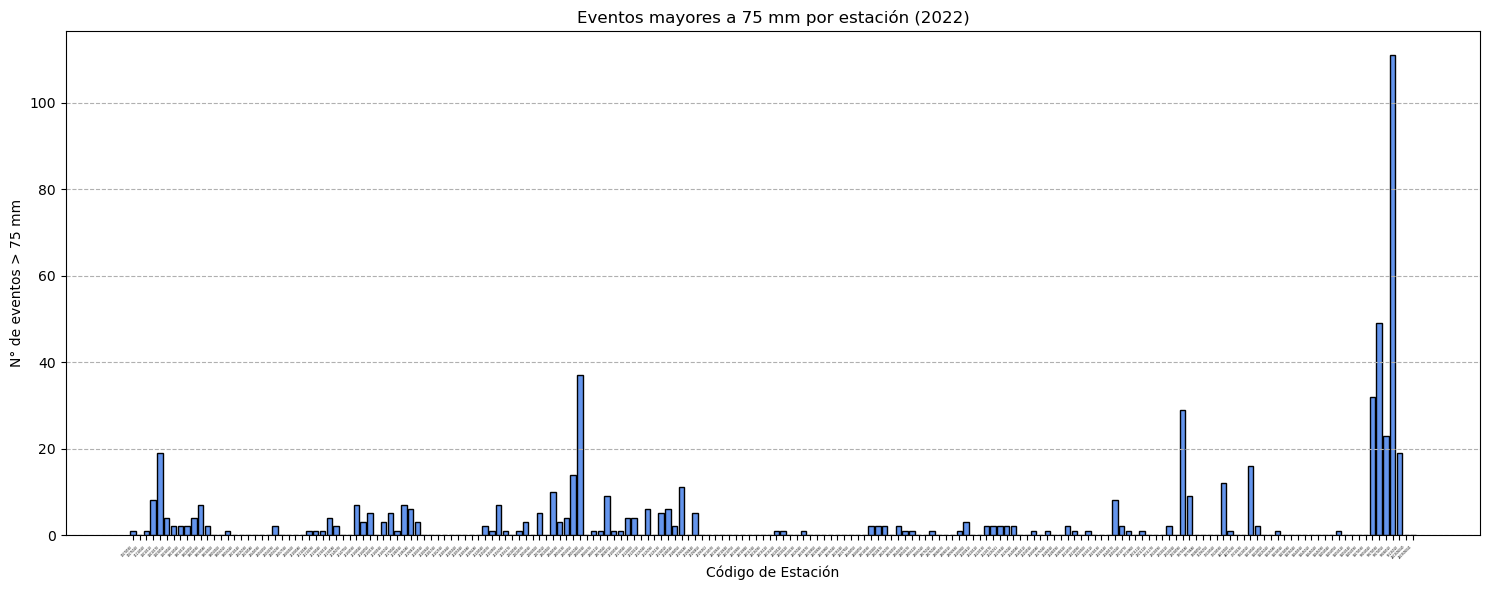

In [4]:

# === Parámetros ===
Umbral = 75
ruta_coord = carpeta_descarga  # Asegúrate de definir 'carpeta_descarga' antes

# === Buscar archivos CSV ===
archivos_csv = glob.glob(os.path.join(ruta_coord, "*.csv"))
lista_df = [pd.read_csv(f) for f in archivos_csv] 
df_total = pd.concat(lista_df, ignore_index=True)

# === Filtrar columnas de interés ===
df_filtrado = df_total[ColumnasInteres].copy()

# === Filtrar por año 2022 ===
df_filtrado["Fecha"] = pd.to_datetime(df_filtrado["Fecha"])
df_2022 = df_filtrado[df_filtrado["Fecha"].dt.year == 2022]
grupos_2022 = dict(tuple(df_2022.groupby("CodigoEstacion")))

# === Estaciones con al menos 328 datos (~10% faltantes) ===
grupos_filtrados = {codigo: df for codigo, df in grupos_2022.items() if len(df) >= 328}

# === Calcular lluvia total anual por estación ===
lluvia_total_2022 = {codigo: df["Valor"].sum() for codigo, df in grupos_filtrados.items()}

# Crear carpeta de salida para lluvia total
carpeta_lluvia = os.path.join(os.getcwd(), "Lluvia_total")
os.makedirs(carpeta_lluvia, exist_ok=True)

# Guardar lluvia total en CSV
df_lluvia_total = pd.DataFrame.from_dict(lluvia_total_2022, orient="index", columns=["LluviaTotal_2022"])
df_lluvia_total.index.name = "CodigoEstacion"
df_lluvia_total.reset_index(inplace=True)
df_lluvia_total.to_csv(os.path.join(carpeta_lluvia, "lluvia_total_2022_por_estacion.csv"), index=False)

print("\n\nLluvia total 2022 por estación\n\n", df_lluvia_total.head())

print("\n\n Estaciones usadas en el análisis \n\n")
for CodigoEstacion, df in grupos_filtrados.items():
    print(f"{CodigoEstacion}: {len(df)}")

# === Crear carpeta de salida para eventos extremos ===
doc_salida = os.path.join(os.getcwd(), "Resultados_Valores_Mayores_Umbra")
os.makedirs(doc_salida, exist_ok=True)

# === Extraer eventos extremos ===
eventos_extremos = []
for codigo, df in grupos_filtrados.items():
    df_mayores_Umbral = df[df["Valor"] >= Umbral].copy()
    df_mayores_Umbral["CodigoEstacion"] = codigo
    eventos_extremos.append(df_mayores_Umbral[["Fecha", "Valor", "CodigoEstacion"]])

df_eventos = pd.concat(eventos_extremos, ignore_index=True)
print("\n\n muestra de eventos \n\n", df_eventos.head(5))
df_eventos.to_csv(os.path.join(doc_salida, "eventos_mayores_umbral_por_estacion.csv"), index=False)

# === Contar número de eventos por estación para la gráfica ===
conteo_eventos = {}
for CodigoEstacion, df in grupos_filtrados.items():
    num_eventos = (df["Valor"] > Umbral).sum()
    conteo_eventos[CodigoEstacion] = num_eventos

# === Estaciones sin eventos extremos ===
estaciones_sin_eventos_extremos = []
for codigo, df in grupos_filtrados.items():
    if df["Valor"].max() < Umbral:
        df = df.copy()
        fecha_max = df.loc[df["Valor"].idxmax(), "Fecha"]
        df_salida = pd.DataFrame({
            "CodigoEstacion": [codigo],
            "FechaMaxPrecipitacion": [fecha_max]
        })
        estaciones_sin_eventos_extremos.append(df_salida)

df_no_eventos = pd.concat(estaciones_sin_eventos_extremos, ignore_index=True)
print("\n\nmuestra de estaciones sin evento \n\n", df_no_eventos.head(5))
df_no_eventos.to_csv(os.path.join(doc_salida, "estaciones_sin_eventos_extremos.csv"), index=False)

# === Graficar ===
estaciones = list(map(str, conteo_eventos.keys()))
eventos = list(conteo_eventos.values())

plt.figure(figsize=(15, 6))
plt.bar(estaciones, eventos, color="cornflowerblue", edgecolor="black")
plt.xlabel("Código de Estación")
plt.ylabel(f"N° de eventos > {Umbral} mm")
plt.title(f"Eventos mayores a {Umbral} mm por estación (2022)")
plt.xticks(rotation=45, ha="right", fontsize=2)
plt.grid(axis="y", linestyle="--", alpha=1)
plt.tight_layout()
plt.show()

### Asignación de coordenadas
Para el análisis espacial se crean geodataframes de estas estaciones. Para esto se recurrió al catalogo de estaciones del IDEAM en CSV, el cual cuenta con las coordenadas de cada una de las estaciones. Asimismo, se garantizó que los datos tuvieran una proyección 9377 mediante un procesamiento en QGIS. 

In [5]:

# Crear carpeta de descarga
carpeta_descarga2 = os.path.join(os.getcwd(), "coords_estaciones")
os.makedirs(carpeta_descarga2, exist_ok=True)

# Zenodo record IDs
record_id = "15514435"  # Puedes poner IDs distintos aquí
lista_df = []
api_url = f"https://zenodo.org/api/records/{record_id}"
respuesta = requests.get(api_url)

record = respuesta.json()
for file in record['files']:
    if "CNE_IDEAM.csv" in file['key']:  # Ajusta según el nombre real
        url_descarga = file['links']['self']
        ruta_csv = os.path.join(carpeta_descarga2, file['key'])
        with requests.get(url_descarga, stream=True) as r:
            with open(ruta_csv, 'wb') as f:
                f.write(r.content)


ruta_csv = ruta_csv = os.path.join(carpeta_descarga2, "CNE_IDEAM.csv")
df_coord = pd.read_csv(ruta_csv)

#El código se pasa a entero para evitar errores
df_coord["Codigo"] = pd.to_numeric(df_coord["CODIGO"], errors="coerce")

#Se buscan las estaciones con eventos extremos
estaciones_eventos = df_eventos["CodigoEstacion"].unique()
estaciones_no_eventos = df_no_eventos["CodigoEstacion"].unique()

#Unir eventos extremos con coordenadas
df_eventos_coord = df_eventos.merge(df_coord, left_on="CodigoEstacion", right_on="Codigo")
df_no_eventos_coord = df_no_eventos.merge(df_coord, left_on="CodigoEstacion", right_on="Codigo")


#Se crea geometría y geodataframe
geometry = [Point(xy) for xy in zip(df_eventos_coord["X"], df_eventos_coord["Y"])]
gdf_eventos = gpd.GeoDataFrame(df_eventos_coord[["Fecha", "Valor", "CodigoEstacion"]], geometry=geometry)
gdf_eventos.set_crs(epsg=9377, inplace=True) 

geometry = [Point(xy) for xy in zip(df_no_eventos_coord["X"], df_no_eventos_coord["Y"])]
gdf_no_eventos = gpd.GeoDataFrame(df_no_eventos_coord[["CodigoEstacion", "FechaMaxPrecipitacion"]], geometry=geometry)
gdf_no_eventos.set_crs(epsg=9377, inplace=True) 
                                  
carpeta_salida = "Resultados_Valores_Mayores_Umbral"
os.makedirs(carpeta_salida, exist_ok=True)

ruta_salida = os.path.join(carpeta_salida,"eventos_extremos_con_geometry.csv")
gdf_eventos.to_csv(ruta_salida, index=False)

ruta2_salida = os.path.join(carpeta_salida,"estaciones_sin_extremos_con_geometry.csv")
gdf_no_eventos.to_csv(ruta2_salida, index=False)


In [6]:
gdf_no_eventos.head(3)

,CodigoEstacion,FechaMaxPrecipitacion,geometry
0,11075020,2022-05-19,POINT (4652293.652 2254998.176)
1,16030100,2022-06-07,POINT (4997950.018 2444786.95)
2,16050100,2022-05-31,POINT (4979759.831 2443928.858)


## Descarga de zonas de intéres
Se descarga la geometría de la zona de interés, esto servirá en un futuro cuando se quiera hacer un filtro por departamento

Descargando: ParteCuencaMagd.dbf
Descargando: SubcuencasMagd.shp
Descargando: SubcuencasMagd.shx
Descargando: ParteCuencaMagd.cpg
Descargando: SubcuencasMagd.dbf
Descargando: SubcuencasMagd.prj
Descargando: ParteCuencaMagd.prj
Descargando: ParteCuencaMagd.shp
Descargando: SubcuencasMagd.cpg
Descargando: ParteCuencaMagd.shx
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Id        1 non-null      object  
 1   geometry  1 non-null      geometry
dtypes: geometry(1), object(1)
memory usage: 148.0+ bytes


<Axes: >

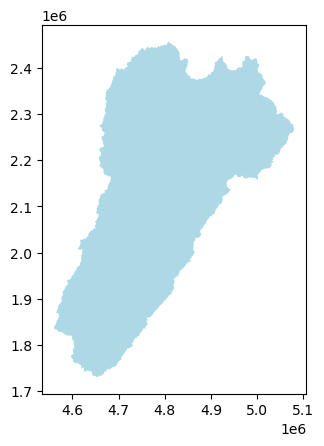

In [7]:
#Visualizar datos

record_id = "15713307"  # 
carpeta_destino = os.path.join(os.getcwd(), "Zona_descargado")
os.makedirs(carpeta_destino, exist_ok=True)

# Construir URL del API
api_url = f"https://zenodo.org/api/records/{record_id}"
respuesta = requests.get(api_url)

if respuesta.status_code == 200:
    record = respuesta.json()
    
    for archivo in record.get("files", []):
        nombre_archivo = archivo["key"]
        
        # Filtrar extensiones típicas de shapefile
        if any(nombre_archivo.endswith(ext) for ext in [".shp", ".shx", ".dbf", ".prj", ".cpg", ".sbn", ".sbx"]):
            url_descarga = archivo["links"]["self"]
            ruta_local = os.path.join(carpeta_destino, nombre_archivo)
            print(f"Descargando: {nombre_archivo}")
            with requests.get(url_descarga, stream=True) as r:
                with open(ruta_local, 'wb') as f:
                    f.write(r.content)
else:
    print(f" Error al acceder al registro Zenodo: {respuesta.status_code}")

ruta_shp = os.path.join(carpeta_destino, "ParteCuencaMagd.shp")  
ZonaEstudio = gpd.read_file(ruta_shp)
type(ZonaEstudio)
ZonaEstudio.info()
ZonaEstudio.head(2)
ZonaEstudio.plot(color="lightblue")

### Filtro espacial
Se filtran las estaciones según los departamentos que se quieren analizar. Anteriormente se clasificaron las zonas de interés.

In [8]:
#limitar los departamentos según los departamentos destacados
Area = ZonaEstudio

#Dejar solo los eventos del área de interés
Eventos = gpd.sjoin(gdf_eventos, Area, how="inner", predicate="intersects")
No_eventos = gpd.sjoin(gdf_no_eventos, Area, how="inner", predicate="intersects")
#Quitar columnas demás
GeoColumnas=["CodigoEstacion","Fecha","Valor","geometry"]
GeoColumnas2=["CodigoEstacion","FechaMaxPrecipitacion","geometry"]

Eventos = Eventos[GeoColumnas]
No_eventos = No_eventos[GeoColumnas2]

ruta_geojson = os.path.join(carpeta_salida, "eventos_extremos.geojson")
Eventos.to_file(ruta_geojson, driver="GeoJSON")
print("\n\n Eventos \n\n ",Eventos)

ruta_geojson2 = os.path.join(carpeta_salida, "eventos_no_extremos.geojson")
No_eventos.to_file(ruta_geojson2, driver="GeoJSON")
print("\n\n No Eventos \n\n ",No_eventos)



 Eventos 

       CodigoEstacion      Fecha  Valor                         geometry
54         21050290 2022-02-27   77.0  POINT (4696677.682 1833616.247)
55         21050290 2022-04-18   78.0  POINT (4696677.682 1833616.247)
56         21110180 2022-11-27   85.0   POINT (4760051.19 1893730.298)
57         21110290 2022-01-25   95.0  POINT (4758947.972 1928398.985)
58         21110290 2022-11-28   75.0  POINT (4758947.972 1928398.985)
..              ...        ...    ...                              ...
338        27030090 2022-09-30   95.0  POINT (4797032.253 2367188.171)
339        27030090 2022-10-24   86.0  POINT (4797032.253 2367188.171)
340        27030090 2022-10-27   79.0  POINT (4797032.253 2367188.171)
341        27030090 2022-11-05   99.0  POINT (4797032.253 2367188.171)
342        27030090 2022-11-23   93.0  POINT (4797032.253 2367188.171)

[289 rows x 4 columns]


 No Eventos 

      CodigoEstacion FechaMaxPrecipitacion                         geometry
4         2101014

In [9]:
No_eventos.crs

<Projected CRS: EPSG:9377>
Name: MAGNA-SIRGAS 2018 / Origen-Nacional
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: Colombia - onshore and offshore. Includes San Andres y Providencia, Malpelo Islands, Roncador Bank, Serrana Bank and Serranilla Bank.
- bounds: (-84.77, -4.23, -66.87, 15.51)
Coordinate Operation:
- name: Colombia Transverse Mercator
- method: Transverse Mercator
Datum: Marco Geocentrico Nacional de Referencia 2018
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

### Cantidad de eventos
Se crea un geodataframe con el número de eventos que tuvo cada estación que superó el umbral

In [10]:
#Reset index convierte en un dataframe estandar
frecuencias = Eventos['CodigoEstacion'].value_counts().reset_index() #Cuenta cuántas veces aparece ese código, añade los titulos
frecuencias.columns = ['CodigoEstacion', 'eventos']  # Renombrar columnas
geometrias = Eventos.groupby('CodigoEstacion')['geometry'].first().reset_index() #first toma el primer valor encontrado de Geomy para esa EST
FrecEventos = pd.merge(frecuencias, geometrias, on='CodigoEstacion')
FrecEventos = gpd.GeoDataFrame(FrecEventos, geometry='geometry').set_crs("EPSG:9377")
print(FrecEventos.head(150))


No_eventos_eventos = No_eventos.copy()
No_eventos_eventos["eventos"] = 0

# Seleccionar columnas de interés para combinar
FrecNoEventos = No_eventos_eventos[["CodigoEstacion", "eventos", "geometry"]]

# estaciones con eventos también tienen las mismas columnas
FrecEventos_final = FrecEventos[["CodigoEstacion", "eventos", "geometry"]]
print(FrecEventos.crs)
print(FrecNoEventos.crs)

# Combinar ambos en un solo GeoDataFrame
TodasEstaciones = pd.concat([FrecEventos, FrecNoEventos], ignore_index=True)
TodasEstaciones = gpd.GeoDataFrame(TodasEstaciones, geometry='geometry')

# Guardar el resultado en GeoJSON
ruta_combinado = os.path.join(carpeta_salida, "frecuencia_eventos_todas_estaciones.geojson")
TodasEstaciones.to_file(ruta_combinado, driver="GeoJSON")

# Vista previa
print("\n\n GeoDataFrame combinado \n\n", TodasEstaciones.head())


    CodigoEstacion  eventos                         geometry
0         23055040       38  POINT (4779265.642 2157074.004)
1         27030090       29  POINT (4797032.253 2367188.171)
2         23050250       16   POINT (4790536.892 2174305.11)
3         23180050       11  POINT (4934048.447 2391359.368)
4         26240170       10  POINT (4729919.538 2394413.076)
..             ...      ...                              ...
63        26050270        1    POINT (4586604.42 1903016.91)
64        26040260        1    POINT (4637423.78 1884778.53)
65        21130040        1  POINT (4723939.545 1898741.563)
66        24015260        1  POINT (4959279.931 2260230.226)
67        24020120        1    POINT (4995055.364 2254077.1)

[68 rows x 3 columns]
EPSG:9377
EPSG:9377


 GeoDataFrame combinado 

    CodigoEstacion  eventos                         geometry
0        23055040       38  POINT (4779265.642 2157074.004)
1        27030090       29  POINT (4797032.253 2367188.171)
2        2305025

## Distribución de eventos
El sistema de coordenadas se pasa a EPSG 3857, ya que es el compatible con el basemap a usar

<GeoAxes: >

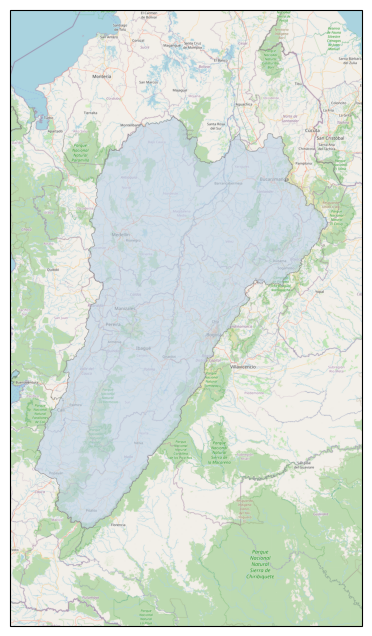

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import matplotlib.patches as mpatches
from matplotlib_scalebar.scalebar import ScaleBar

# Crear mapa base (OSM)
tiler = cimgt.OSM()
mercator = tiler.crs  # EPSG:3857

# Convertir todos los datos a la proyección Web Mercator
# (no usamos set_crs porque ya deben tener su CRS bien definido)
FrecEventos_merc = FrecEventos.to_crs(mercator)
No_eventos_merc = No_eventos.to_crs(mercator)
ZonaEstudio_merc = ZonaEstudio.to_crs(mercator)

# Crear figura y ejes con proyección
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': mercator})
ax.add_image(tiler, 8)  # Zoom nivel 8

# Plot zona de estudio (color fijo, sin columna 'grupo')
ZonaEstudio_merc.plot(
    ax=ax,
    facecolor="#BFD3E6",  # azul claro
    edgecolor="gray",
    linewidth=0.5,
    alpha=0.6,
    transform=mercator
)

# Plot estaciones con evento



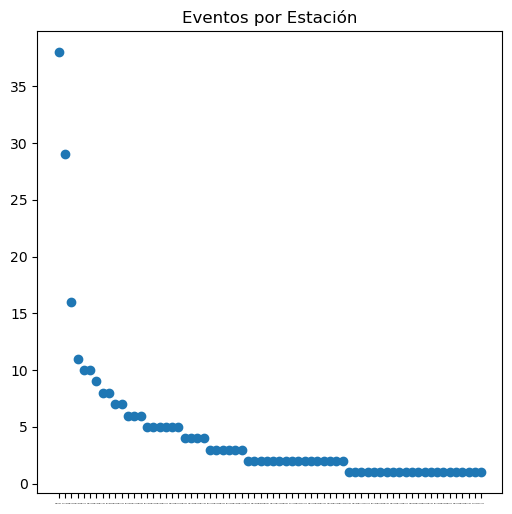

In [12]:
x0 = FrecEventos["CodigoEstacion"]
x = list(map(str, x0))
y = FrecEventos["eventos"]
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_title("Eventos por Estación", fontsize=12)
plt.xticks(fontsize=1) 
plt.yticks(fontsize=10) 
plt.scatter(x,y)
plt.show()

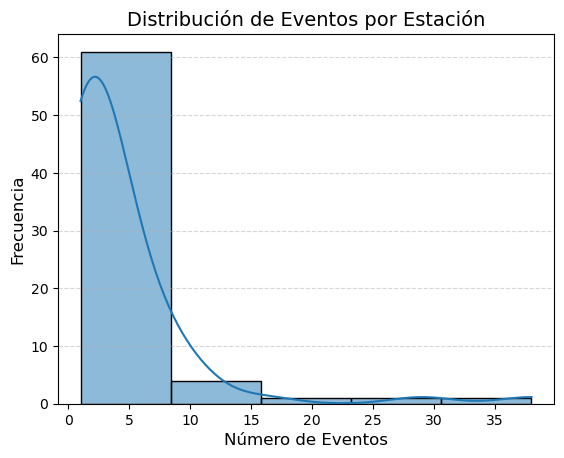

In [13]:
HistogramaEventos = sns.histplot(FrecEventos["eventos"], kde = True, bins = 5)   # Cálculo automático de bins (reglas de Sturges/Freedman-Diaconis) si no se indica
plt.title("Distribución de Eventos por Estación", fontsize=14)
plt.xlabel("Número de Eventos", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

In [14]:
#Se convierte los puntos a 4326 que es lo que lee GEE
FrecEventos_4326 = FrecEventos.to_crs(epsg=4326)
FrecEventos_4326["lat"] = FrecEventos_4326.geometry.y
FrecEventos_4326["lon"] = FrecEventos_4326.geometry.x
FrecEventos_4326.head(3)

,CodigoEstacion,eventos,geometry,lat,lon
0,23055040,38,POINT (-74.99293 5.41829),5.418288,-74.992928
1,27030090,29,POINT (-74.83933 7.31931),7.319306,-74.839333
2,23050250,16,POINT (-74.89169 5.57447),5.574472,-74.891694


### Densidad espacial de eventos (Hexbin)

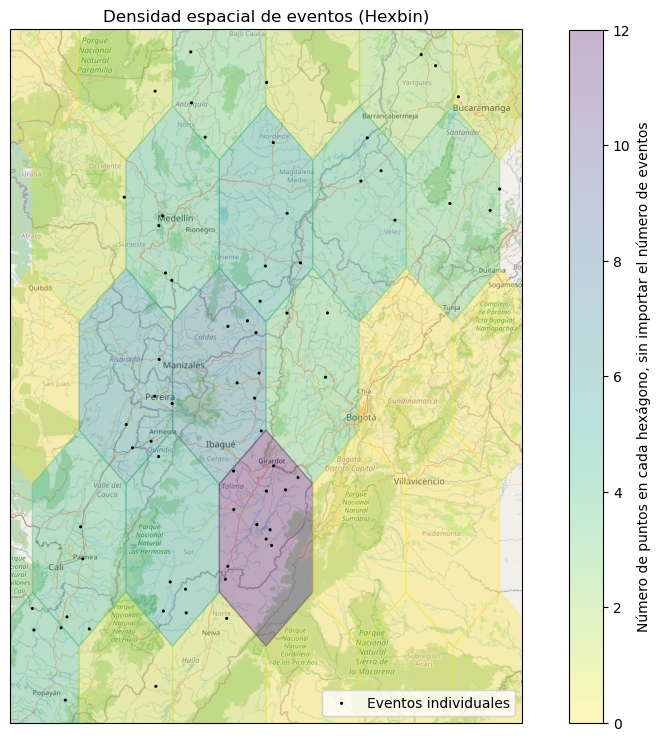

In [15]:
tiler = cimgt.OSM()
mercator = tiler.crs
FrecEventos_3857 = FrecEventos_4326.to_crs(mercator)

f, ax = plt.subplots(1, figsize=(12, 9), subplot_kw={'projection': mercator})

ax.add_image(tiler, 8, alpha=1)
ax.set_extent([
    FrecEventos_3857.geometry.x.min() - 20000,
    FrecEventos_3857.geometry.x.max() + 20000,
    FrecEventos_3857.geometry.y.min() - 20000,
    FrecEventos_3857.geometry.y.max() + 20000
], crs=mercator)

hb = ax.hexbin(
    FrecEventos_3857.geometry.x,   # primero longitud (x)
    FrecEventos_3857.geometry.y,   # luego latitud (y)
    gridsize=5, 
    linewidths=1,
    alpha=0.3, 
    cmap='viridis_r'
)

ax.scatter(
    FrecEventos_3857.geometry.x, 
    FrecEventos_3857.geometry.y,
    color='black',      # o el que prefieras
    edgecolor='none',  # borde blanco para destacar
    s=5, 
    alpha=1, 
    label='Eventos individuales'
)

plt.colorbar(hb, label='Número de puntos en cada hexágono, sin importar el número de eventos')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.legend()
plt.title('Densidad espacial de eventos (Hexbin)')
plt.show()

### Densidad espacial de eventos (KDE)

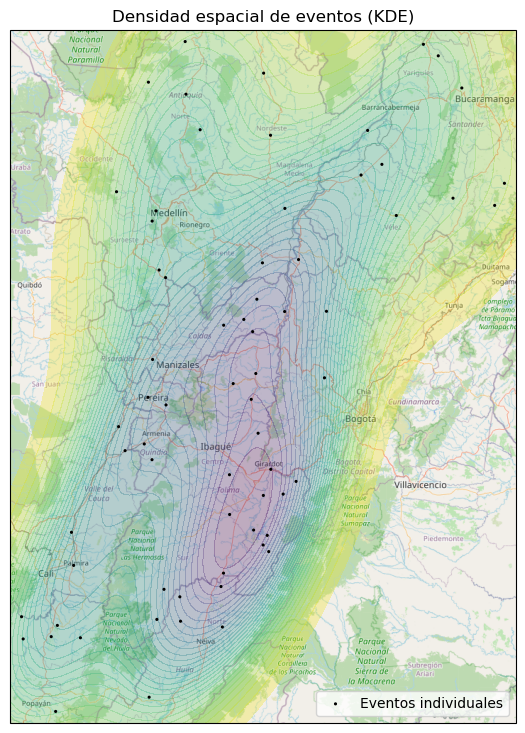

In [16]:
tiler = cimgt.OSM()
mercator = tiler.crs

FrecEventos_3857 = FrecEventos_4326.to_crs(mercator)

f, ax = plt.subplots(1, figsize=(12, 9), subplot_kw={'projection': mercator})

ax.add_image(tiler, 8, alpha=1)
ax.set_extent([
    FrecEventos_3857.geometry.x.min() - 10000,
    FrecEventos_3857.geometry.x.max() + 10000,
    FrecEventos_3857.geometry.y.min() - 10000,
    FrecEventos_3857.geometry.y.max() + 10000
], crs=mercator)

sns.kdeplot(
    x = FrecEventos_3857.geometry.x,   # primero longitud (x)
    y = FrecEventos_3857.geometry.y,   # luego latitud (y)
    levels=30, 
    fill=True,
    alpha=0.3, 
    cmap='viridis_r',
    ax = ax)

ax.scatter(
    FrecEventos_3857.geometry.x, 
    FrecEventos_3857.geometry.y,
    color='black',      # o el que prefieras
    edgecolor='none',  # borde blanco para destacar
    s=5, 
    alpha=1, 
    label='Eventos individuales',
    transform=mercator)


ax.legend()
ax.set_title('Densidad espacial de eventos (KDE)')
plt.show()

### Centrografía + KDE

La discrepancia entre la media y la media se debe a la asimetría

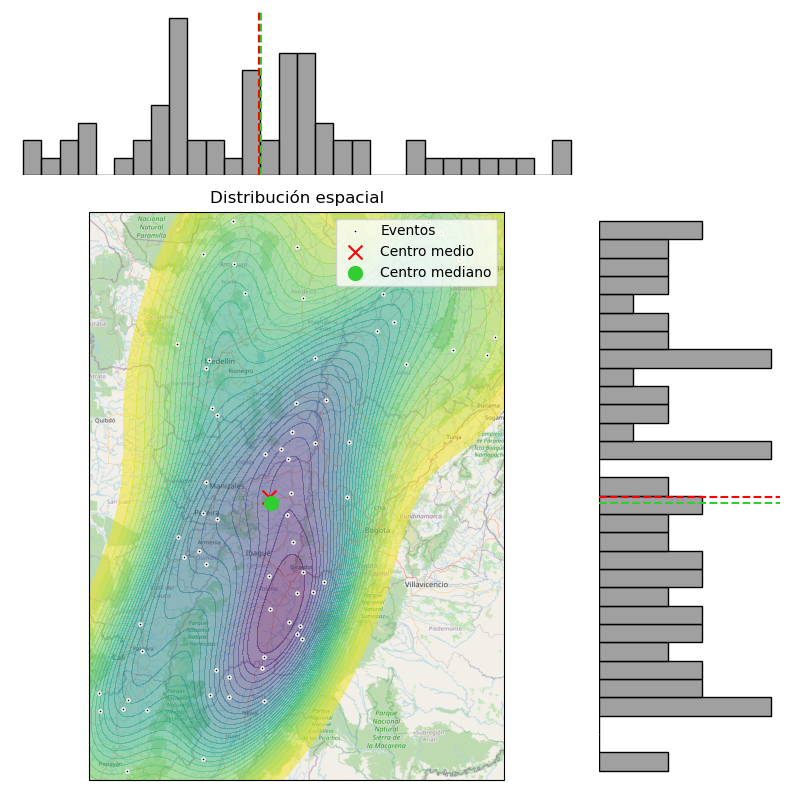

In [17]:
# 1. Preparar datos
tiler = cimgt.OSM()
mercator = tiler.crs
FrecEventos_3857 = FrecEventos_4326.to_crs(mercator)
coords = list(zip(FrecEventos_3857.geometry.x, FrecEventos_3857.geometry.y))


mean_center = centrography.mean_center(coords)
med_center = centrography.euclidean_median(coords)

x = FrecEventos_3857.geometry.x
y = FrecEventos_3857.geometry.y

# 2. Crear diseño tipo jointplot con 3 ejes: mapa + histogramas
fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(4, 4)

# Ejes principales (mapa con cartopy)
ax_main = fig.add_subplot(gs[1:4, 0:3], projection=mercator)
ax_main.add_image(tiler, 8)
ax_main.set_extent([
    x.min() - 10000, x.max() + 10000,
    y.min() - 10000, y.max() + 10000
], crs=mercator)

# 3. Dibujo de puntos, KDE, centros
sns.kdeplot(
    x=x, y=y,
    fill=True, levels=30, alpha=0.5, cmap="viridis_r",
    ax=ax_main
)
ax_main.scatter(x, y, color='black', s=5, alpha=1, edgecolors='white', transform=mercator, label='Eventos')
ax_main.scatter(*mean_center, color='red', marker='x', s=100, transform=mercator, label='Centro medio')
ax_main.scatter(*med_center, color='limegreen', marker='o', s=100, transform=mercator, label='Centro mediano')
ax_main.legend(loc='upper right')
ax_main.set_title('Distribución espacial')

# 4. Histograma superior (x)
ax_histx = fig.add_subplot(gs[0, 0:3], sharex=ax_main)
sns.histplot(x=x, bins=30, ax=ax_histx, color='gray')
ax_histx.axvline(mean_center[0], color='red', linestyle='--')
ax_histx.axvline(med_center[0], color='limegreen', linestyle='--')
ax_histx.axis('off')

# 5. Histograma derecho (y)
ax_histy = fig.add_subplot(gs[1:4, 3], sharey=ax_main)
sns.histplot(y=y, bins=30, ax=ax_histy, color='gray')
ax_histy.axhline(mean_center[1], color='red', linestyle='--')
ax_histy.axhline(med_center[1], color='limegreen', linestyle='--')
ax_histy.axis('off')

plt.tight_layout()
plt.show()


### Dispersión: elipse estándar
Elipse trazada a partir de los datos que refleja tanto su centro como su dispersión.

en promedio las fotos se tomaron a una distancia de 188874.89621742888  m desde el centro, aunque en este caso no aplica tan así, en este caso no es tan buena medida de caracterización


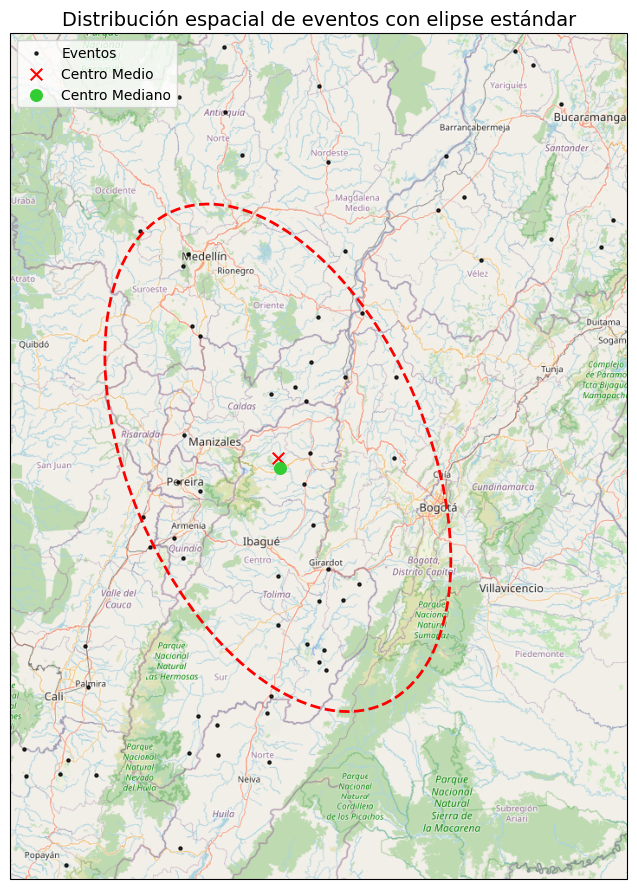

In [18]:
# Extraer coordenadas x, y
x = FrecEventos_3857.geometry.x
y = FrecEventos_3857.geometry.y
coords = list(zip(x, y))

# Calcular centros y parámetros de la elipse
mean_center = centrography.mean_center(coords)
med_center = centrography.euclidean_median(coords)
major, minor, rotation = centrography.ellipse(coords)

# Crear figura con mapa base
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': mercator})
ax.add_image(tiler, 8)

# Establecer extensión del mapa en torno a los puntos
buffer = 10000  # metros
ax.set_extent([
    x.min() - buffer,
    x.max() + buffer,
    y.min() - buffer,
    y.max() + buffer
], crs=mercator)

# Graficar puntos de eventos
ax.scatter(x, y, s=5, color='black', alpha=0.8, transform=mercator, label="Eventos")

# Graficar centros
ax.scatter(*mean_center, color='red', marker='x', s=70, label='Centro Medio', transform=mercator)
ax.scatter(*med_center, color='limegreen', marker='o', s=70, label='Centro Mediano', transform=mercator)

# Agregar elipse estándar
ellipse = Ellipse(
    xy=mean_center,
    width=major * 2,
    height=minor * 2,
    angle=np.degrees(rotation),
    edgecolor='red',
    facecolor='none',
    linestyle='--',
    linewidth=2
)

# Importante: añadir la elipse como patch con la transformación
ax.add_patch(ellipse)
ellipse.set_transform(mercator)  # Para que se dibuje correctamente en coordenadas del mapa

# Título y leyenda
ax.set_title("Distribución espacial de eventos con elipse estándar", fontsize=14)
ax.legend()
plt.tight_layout()
print("en promedio las fotos se tomaron a una distancia de", centrography.std_distance(coords)," m desde el centro, aunque en este caso no aplica tan así, en este caso no es tan buena medida de caracterización")
plt.show()

### Extensión: Convex hull
Forma convexa más ajustada que encierra los eventos. Por convexa, nos referimos a que la forma nunca “retrocede” sobre sí misma; no tiene depresiones, valles, crestas o agujeros. Todos sus ángulos interiores son menores de 180 grados. 

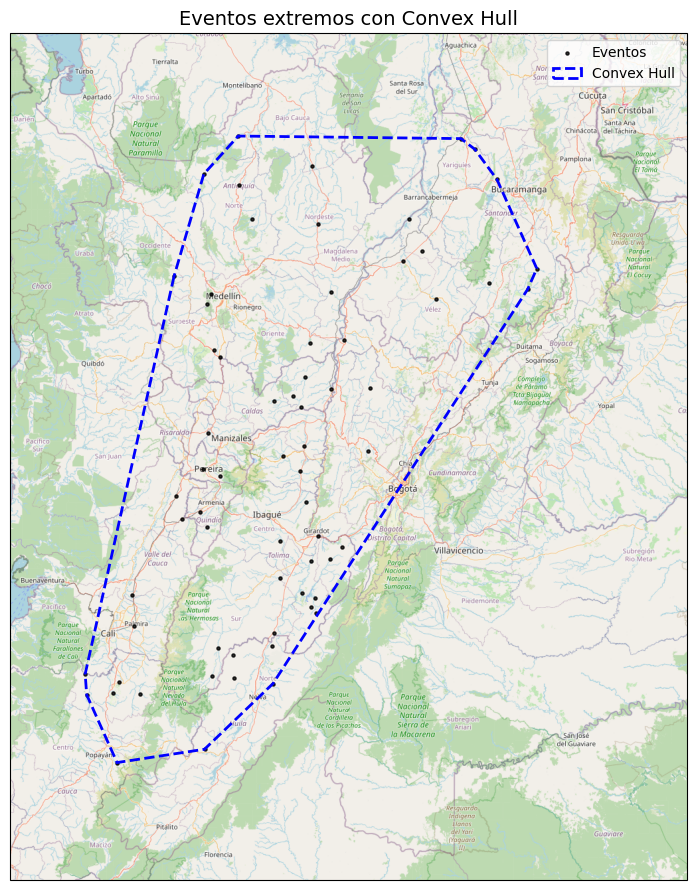

In [19]:
# Extraer coordenadas x, y
FrecEventos_3857 = FrecEventos_4326.to_crs(mercator)
x = FrecEventos_3857.geometry.x
y = FrecEventos_3857.geometry.y
coords = list(zip(x, y))

# Crear figura con mapa base
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': mercator})
ax.add_image(tiler, 8)

# Graficar puntos de eventos
ax.scatter(x, y, s=5, color='black', alpha=0.8, transform=mercator, label="Eventos")

#Convexhull
convex_hull_vertices = centrography.hull(coords)

# Crear y agregar el polígono del convex hull
hull_polygon = Polygon(convex_hull_vertices, closed=True,
                       facecolor='none', edgecolor='blue',
                       linewidth=2, linestyle='--', label='Convex Hull')

# IMPORTANTE: Asignar proyección
hull_polygon.set_transform(mercator)
ax.add_patch(hull_polygon)
    
# Ajustes finales
ax.set_title("Eventos extremos con Convex Hull", fontsize=14)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

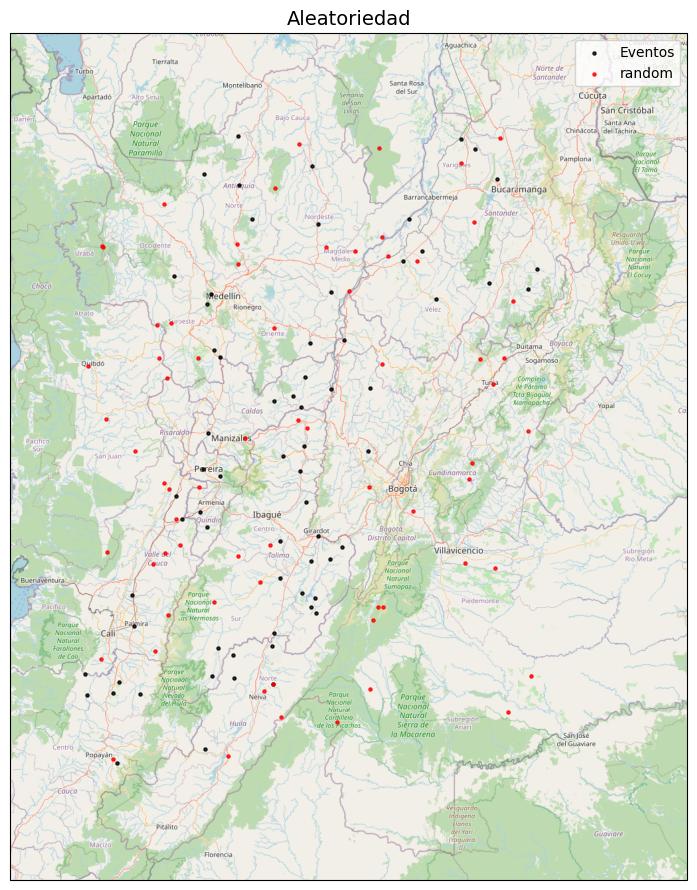

In [20]:
# Extraer coordenadas x, y

x = FrecEventos_3857.geometry.x
y = FrecEventos_3857.geometry.y
coords = list(zip(x, y))

## Crear figura con mapa base
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': mercator})
ax.add_image(tiler, 8)

# Graficar puntos de eventos
ax.scatter(x, y, s=5, color='black', alpha=0.8, transform=mercator, label="Eventos")

xmin, ymin, xmax, ymax = FrecEventos_3857.total_bounds
num_points = len(coords)
random_x = np.random.uniform(xmin, xmax, num_points)
random_y = np.random.uniform(ymin, ymax, num_points)
ax.scatter(random_x, random_y, s=5, color='red', alpha=0.8, transform=mercator, label="random")

# Ajustes finales
ax.set_title("Aleatoriedad", fontsize=14)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Temperatura, Humedad y NDVI

La idea es encontrar un modelo para analizar los días de lluvia con mas de 100 mm con la elevación, temperatura y humedad. Al ser las varibles más representativas de acuerdo con Fang. J, et al (2013) en el estudio *"Spatial downscaling of TRMM precipitation data based on te orographical effect and meteorological conditions in a mountainous area"*.

Por lo anterior, se encontrará la temperatura máxima y humedad promedio del día anterior de los eventos para las estaciones que superaron el umbral. Mientras que para las estaciones que no superaron el umbral definido se analiza las mismas variables para la fecha en la que hubo el evento máximo de precipitación. Ya que la idea es analizar las precipitaciones máximas y las condiciones que condicionan ante estos eventos. 

Para analizar la temperatura máxima se utiliza la base de datos de ERA 5 (ECMWF/ERA5_LAND/DAILY)
En cuanto a la humedad se utiliza la base de datos de ERA 5 (ECMWF/ERA5/DAILY)para el analisis de humedad especifica para evitar multicolinealidad con la temperatura.

La temperatura està correlacionada con la elevaciòn y la humedad. Por esto, se calcula el NDVI como intento de mejorar el modelo. Se asume que en el 2022 el ndvi se mantuvo constante

In [21]:
##Regresamos a los geodataframe que tienen las fechas asignadas
Eventos_4326 = Eventos.to_crs("EPSG:4326")
No_eventos_4326 = No_eventos.to_crs("EPSG:4326")
No_eventos_4326 = No_eventos_4326.rename(columns={'FechaMaxPrecipitacion': 'Fecha'})

print(Eventos_4326.head(113))
print(No_eventos_4326.head(100))


     CodigoEstacion      Fecha  Valor                   geometry
54         21050290 2022-02-27   77.0   POINT (-75.7285 2.49128)
55         21050290 2022-04-18   78.0   POINT (-75.7285 2.49128)
56         21110180 2022-11-27   85.0  POINT (-75.15972 3.03603)
57         21110290 2022-01-25   95.0  POINT (-75.17031 3.34956)
58         21110290 2022-11-28   75.0  POINT (-75.17031 3.34956)
..              ...        ...    ...                        ...
162        23050250 2022-12-23  110.0  POINT (-74.89169 5.57447)
163        23055040 2022-01-16  134.0  POINT (-74.99293 5.41829)
164        23055040 2022-01-22  123.0  POINT (-74.99293 5.41829)
165        23055040 2022-01-24  132.0  POINT (-74.99293 5.41829)
166        23055040 2022-02-17  116.0  POINT (-74.99293 5.41829)

[113 rows x 4 columns]
    CodigoEstacion      Fecha                   geometry
4         21010140 2022-01-26  POINT (-76.36083 1.86439)
5         21025030 2022-10-13  POINT (-75.73622 2.07917)
6         21030080 2022-0

In [22]:

from datetime import timedelta

# Inicializar Earth Engine (si no lo has hecho)
ee.Initialize()

def calculate_humidity(img):
    """Calcula humedad específica usando temperatura y punto de rocío."""
    try:
        t = img.select('temperature_2m').subtract(273.15)  # Kelvin -> Celsius
        td = img.select('dewpoint_temperature_2m').subtract(273.15)
        
        # Constantes como imágenes EE
        c1 = ee.Image(6.112)
        c2 = ee.Image(17.67)
        c3 = ee.Image(243.5)
        c4 = ee.Image(0.622)
        c5 = ee.Image(1000)
        c6 = ee.Image(0.378)
        
        # Fórmula Magnus-Tetens
        es = c1.multiply(ee.Image.exp(c2.multiply(t).divide(t.add(c3))))
        e = c1.multiply(ee.Image.exp(c2.multiply(td).divide(td.add(c3))))
        q = c4.multiply(e).divide(c5.subtract(c6.multiply(e)))
        return q.rename('specific_humidity')
    except Exception as e:
        print(f"Error en calculate_humidity: {e}")
        return None

def get_prev_day_climate(row):
    """Obtiene clima del día anterior y NDVI 2022 para una fila del GeoDataFrame."""
    try:
        # Verificar geometría y fecha
        if row.geometry.is_empty or pd.isna(row['Fecha']):
            print(f"Fila {row.name}: Geometría vacía o fecha inválida.")
            return {
                'temp_max_prev_day': None,
                'humidity_avg_prev_day': None,
                'ndvi_2022': None
            }

        # Extraer coordenadas
        lon, lat = row.geometry.x, row.geometry.y
        point = ee.Geometry.Point(lon, lat)

        # Fechas (manejo de timezone si es necesario)
        event_date = pd.to_datetime(row['Fecha'])
        prev_date = (event_date - timedelta(days=1)).strftime('%Y-%m-%d')

        # --- ERA5: Temperatura y Humedad ---
        era5 = ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY") \
            .filterDate(prev_date, ee.Date(prev_date).advance(1, 'day')) \
            .select(['temperature_2m', 'dewpoint_temperature_2m'])

        # Verificar si hay datos
        if era5.size().getInfo() == 0:
            print(f"Fila {row.name}: No hay datos ERA5 para {prev_date}.")
            era5_result = {'temp_max_prev_day': None, 'humidity_avg_prev_day': None}
        else:
            temp_max = era5.select('temperature_2m').max().subtract(273.15).rename('temp_max_prev_day')
            humidity_avg = era5.map(calculate_humidity).mean().rename('humidity_avg_prev_day')
            
            era5_result = ee.Image.cat(temp_max, humidity_avg) \
                .reduceRegion(
                    reducer=ee.Reducer.mean(),
                    geometry=point,
                    scale=1000,
                    maxPixels=1e9
                ).getInfo() or {}  # Si falla, devuelve diccionario vacío

        # --- MODIS NDVI 2022 ---
        modis_ndvi = ee.ImageCollection('MODIS/061/MOD13Q1') \
            .filterDate('2022-01-01', '2022-12-31') \
            .filterBounds(point) \
            .select('NDVI')

        if modis_ndvi.size().getInfo() == 0:
            print(f"Fila {row.name}: No hay datos MODIS NDVI para 2022.")
            ndvi_value = None
        else:
            ndvi_img = modis_ndvi.mean()
            ndvi_dict = ndvi_img.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=point,
                scale=250,
                maxPixels=1e9
            ).getInfo() or {}
            ndvi_value = ndvi_dict.get('NDVI')
            if ndvi_value is not None:
                ndvi_value = ndvi_value / 10000.0  # Reescalar

        return {
            'temp_max_prev_day': era5_result.get('temp_max_prev_day'),
            'humidity_avg_prev_day': era5_result.get('humidity_avg_prev_day'),
            'ndvi_2022': ndvi_value
        }

    except Exception as e:
        print(f"Error crítico en fila {row.name}: {str(e)}")
        return {
            'temp_max_prev_day': None,
            'humidity_avg_prev_day': None,
            'ndvi_2022': None
        }

def process_gdf(gdf):
    """Procesa un GeoDataFrame completo."""
    # Convertir fechas y eliminar inválidas
    gdf['Fecha'] = pd.to_datetime(gdf['Fecha'], errors='coerce')
    gdf = gdf.dropna(subset=['Fecha']).copy()

    # Aplicar función a cada fila
    results = []
    for idx, row in gdf.iterrows():
        results.append(get_prev_day_climate(row))

    # Crear DataFrame de resultados y unirlo al original
    results_df = pd.DataFrame(results)
    final_gdf = pd.concat([gdf.reset_index(drop=True), results_df.reset_index(drop=True)], axis=1)

    return final_gdf

In [23]:
ee.Initialize(project='my-project-analisis-geoesp')

In [24]:
#Procesar  datos
Eventos_4326_procesado = process_gdf(Eventos_4326.copy())
No_eventos_4326_procesado = process_gdf(No_eventos_4326.copy())

print(Eventos_4326_procesado[['CodigoEstacion', 'Fecha', 'temp_max_prev_day', 'humidity_avg_prev_day','ndvi_2022','geometry']].head(100))
print(No_eventos_4326_procesado[['CodigoEstacion', 'Fecha', 'temp_max_prev_day', 'humidity_avg_prev_day','ndvi_2022','geometry']].head(100))

# Verificar resultados
#print(No_eventos_4326_procesado)
Eventos_4326_HT= Eventos_4326_procesado[['CodigoEstacion', 'Fecha', 'temp_max_prev_day', 'humidity_avg_prev_day','ndvi_2022','geometry']].copy()
No_eventos_4326_HT=No_eventos_4326_procesado[['CodigoEstacion', 'Fecha', 'temp_max_prev_day', 'humidity_avg_prev_day','ndvi_2022','geometry']].copy()
No_eventos_4326_HT.info()

    CodigoEstacion      Fecha  temp_max_prev_day  humidity_avg_prev_day  \
0         21050290 2022-02-27          22.890573               0.012256   
1         21050290 2022-04-18          21.716150               0.012479   
2         21110180 2022-11-27          26.974146               0.013819   
3         21110290 2022-01-25          35.703394               0.011679   
4         21110290 2022-11-28          28.711191               0.014738   
..             ...        ...                ...                    ...   
95        23050250 2022-02-07          27.348962               0.012402   
96        23050250 2022-02-13          30.064874               0.012666   
97        23050250 2022-03-03          26.929468               0.013371   
98        23050250 2022-03-21          29.063531               0.013332   
99        23050250 2022-04-04          30.114801               0.011770   

    ndvi_2022                   geometry  
0    0.654248   POINT (-75.7285 2.49128)  
1    0.654248

In [25]:
No_eventos_4326_HT=No_eventos_4326_procesado[['CodigoEstacion', 'Fecha', 'temp_max_prev_day', 'humidity_avg_prev_day','ndvi_2022','geometry']].copy()
No_eventos_4326_HT['Eventos'] = 0
print(No_eventos_4326_HT)

    CodigoEstacion      Fecha  temp_max_prev_day  humidity_avg_prev_day  \
0         21010140 2022-01-26          17.732080               0.009508   
1         21025030 2022-10-13          26.238794               0.012106   
2         21030080 2022-06-09          21.910532               0.011028   
3         21040030 2022-02-19          19.649530               0.009583   
4         21050250 2022-09-19          19.298654               0.008258   
..             ...        ...                ...                    ...   
69        27011270 2022-09-15          20.688623               0.010107   
70        27020190 2022-09-21          19.772211               0.009940   
71        27020260 2022-07-12          21.672021               0.014497   
72      2401500040 2022-04-19          17.393457               0.008893   
73      2403500041 2022-09-30          18.148477               0.007069   

    ndvi_2022                   geometry  Eventos  
0    0.611004  POINT (-76.36083 1.86439)       

In [26]:
####Desde aquí se pierden las fechas

In [27]:
# Agrupar por CodigoEstacion y calcular promedios
agrupado = Eventos_4326_HT.groupby('CodigoEstacion').agg({
    'temp_max_prev_day': 'mean',
    'humidity_avg_prev_day': 'mean',
    'ndvi_2022':'mean',
    'geometry': 'first'
}).reset_index()

# Calcular cantidad de eventos por estación
conteo = Eventos_4326_HT.groupby('CodigoEstacion').size().reset_index(name='Eventos')

# Unir el conteo al GeoDataFrame agrupado
EventosC_4326_HT = pd.merge(agrupado, conteo, on='CodigoEstacion')

# Convertir a GeoDataFrame
import geopandas as gpd
EventosC_4326_HT = gpd.GeoDataFrame(EventosC_4326_HT, geometry='geometry', crs=Eventos_4326_HT.crs)


In [28]:

print(EventosC_4326_HT.head(5))
print(No_eventos_4326_HT.head(5))

   CodigoEstacion  temp_max_prev_day  humidity_avg_prev_day  ndvi_2022  \
0        21050290          22.303362               0.012367   0.654248   
1        21110180          26.974146               0.013819   0.564443   
2        21110290          32.207292               0.013208   0.524504   
3        21130040          22.305444               0.010968   0.590904   
4        21130110          23.683594               0.010663   0.689222   

                    geometry  Eventos  
0   POINT (-75.7285 2.49128)        2  
1  POINT (-75.15972 3.03603)        1  
2  POINT (-75.17031 3.34956)        2  
3  POINT (-75.48467 3.08064)        1  
4        POINT (-75.49 3.27)        5  
   CodigoEstacion      Fecha  temp_max_prev_day  humidity_avg_prev_day  \
0        21010140 2022-01-26          17.732080               0.009508   
1        21025030 2022-10-13          26.238794               0.012106   
2        21030080 2022-06-09          21.910532               0.011028   
3        21040030 2

## Topografía: 
NASADEM es un reprocesamiento de datos SRTM, 
con mayor precisión gracias a la incorporación de datos auxiliares de 
los conjuntos de datos ASTER GDEM, ICESat GLAS y PRISM. Las mejoras de 
procesamiento más significativas incluyen la reducción de vacíos mediante un 
desdoblamiento de fase mejorado y el uso de datos ICESat GLAS para el control.

Se debe importar EE y luego autenticar con 
ee.Authenticate()
loggearse con la cuenta de GEE y escribir el código, en caso que no sea así, escribir en el cmd earthengine authenticate --force

In [29]:
nasadem = ee.Image("NASA/NASADEM_HGT/001")

In [30]:
def get_elevation(lat, lon):
    point = ee.Geometry.Point([lon, lat])
    elev = nasadem.sample(region=point, scale=30).first()
    try:
        return elev.get("elevation").getInfo()
    except:
        return None

In [31]:
EventosC_4326_HT["lat"] = EventosC_4326_HT.geometry.y
EventosC_4326_HT["lon"] = EventosC_4326_HT.geometry.x

EventosC_4326_HT["elevacion"] = EventosC_4326_HT.apply(lambda row: get_elevation(row.lat, row.lon), axis=1)
print("\n\n Eventos \n\n",EventosC_4326_HT)

No_eventos_4326_HT["lat"] = No_eventos_4326_HT.geometry.y
No_eventos_4326_HT["lon"] = No_eventos_4326_HT.geometry.x

No_eventos_4326_HT["elevacion"] = No_eventos_4326_HT.apply(lambda row: get_elevation(row.lat, row.lon), axis=1)
print("\n\n Sin Eventos \n\n",No_eventos_4326_HT)
 



 Eventos 

     CodigoEstacion  temp_max_prev_day  humidity_avg_prev_day  ndvi_2022  \
0         21050290          22.303362               0.012367   0.654248   
1         21110180          26.974146               0.013819   0.564443   
2         21110290          32.207292               0.013208   0.524504   
3         21130040          22.305444               0.010968   0.590904   
4         21130110          23.683594               0.010663   0.689222   
..             ...                ...                    ...        ...   
63        26255020          25.631410               0.014328   0.640826   
64        27010770          24.512331               0.009946   0.383052   
65        27011110          23.089685               0.010912   0.506613   
66        27020210          21.587625               0.011007   0.685878   
67        27030090          29.106804               0.016698   0.662604   

                     geometry  Eventos       lat        lon  elevacion  
0    POINT (

In [32]:
pd.set_option('display.max_rows', None)       # sin límite de filas
pd.set_option('display.max_columns', None)    # sin límite de columnas
pd.set_option('display.width', None)          # ancho completo
pd.set_option('display.max_colwidth', None)   # no truncar contenido de celdas
#No_eventos_4326_HT.drop('Fecha',axis=1)
# Mostrar el GeoDataFrame completo
print(EventosC_4326_HT)
print(No_eventos_4326_HT)

    CodigoEstacion  temp_max_prev_day  humidity_avg_prev_day  ndvi_2022  \
0         21050290          22.303362               0.012367   0.654248   
1         21110180          26.974146               0.013819   0.564443   
2         21110290          32.207292               0.013208   0.524504   
3         21130040          22.305444               0.010968   0.590904   
4         21130110          23.683594               0.010663   0.689222   
5         21130180          29.931863               0.012618   0.696991   
6         21160030          25.981607               0.013375   0.707343   
7         21160040          25.823553               0.014189   0.715161   
8         21160050          24.582141               0.012891   0.674570   
9         21160160          23.404896               0.012073   0.489996   
10        21165010          28.777231               0.014650   0.693274   
11        21170020          29.617090               0.014996   0.594639   
12        21180160       

## Datos

In [33]:
#print(EventosC_4326_HT.head(3))
#print("\n\n")
#print(No_eventos_4326_HT.head(3))
#No_eventos_4326_HT.drop('Fecha', axis=1)
#print("\n\n")
#print(No_eventos_4326_HT.head(10))


# 1. Asegurar que las columnas sean las mismas y en el mismo orden
No_eventos_4326_HT = No_eventos_4326_HT[EventosC_4326_HT.columns]

# 2. Igualar tipos de datos
No_eventos_4326_HT = No_eventos_4326_HT.astype(EventosC_4326_HT.dtypes.to_dict())

# 3. Resetear índice por seguridad
EventosC_4326_HT = EventosC_4326_HT.reset_index(drop=True)
No_eventos_4326_HT = No_eventos_4326_HT.reset_index(drop=True)

# 4. Concatenar
Todo_4326 = pd.concat([EventosC_4326_HT, No_eventos_4326_HT], ignore_index=True)

# 5. Asegurar que siga siendo GeoDataFrame
Todo_4326 = gpd.GeoDataFrame(Todo_4326, geometry='geometry', crs=EventosC_4326_HT.crs)

# 6. Verificar resultado
print("\n>>> Verificación de NaNs por columna:")
print(Todo_4326.isna().sum())
print('\n\n')
print(Todo_4326)



>>> Verificación de NaNs por columna:
CodigoEstacion           0
temp_max_prev_day        0
humidity_avg_prev_day    0
ndvi_2022                0
geometry                 0
Eventos                  0
lat                      0
lon                      0
elevacion                0
dtype: int64



     CodigoEstacion  temp_max_prev_day  humidity_avg_prev_day  ndvi_2022  \
0          21050290          22.303362               0.012367   0.654248   
1          21110180          26.974146               0.013819   0.564443   
2          21110290          32.207292               0.013208   0.524504   
3          21130040          22.305444               0.010968   0.590904   
4          21130110          23.683594               0.010663   0.689222   
5          21130180          29.931863               0.012618   0.696991   
6          21160030          25.981607               0.013375   0.707343   
7          21160040          25.823553               0.014189   0.715161   
8          2116005

### Ptotal

In [50]:
dicc_lluvia_total = lluvia_total_2022
if 'Todo_4326' in locals():
    Todo_4326['Ptotal'] = Todo_4326['CodigoEstacion'].map(dicc_lluvia_total)
print(Todo_4326.head(100))

if 'Todo_4326' in locals():
    # Crear subcarpeta con marca de tiempo para evitar sobrescribir
    output_folder = 'YXfinal'
    
    output_path = os.path.join(output_folder)
    
    if not os.path.exists(output_path):
        os.makedirs(output_path)
    
    # Guardar en múltiples formatos
    base_filename = 'DatosFinales'
    
    # 1. Shapefile (compatible con GIS)
    shp_path = os.path.join(output_path, f'{base_filename}.shp')
    Todo_4326.to_file(shp_path)
    
    # 2. GeoJSON (para web)
    geojson_path = os.path.join(output_path, f'{base_filename}.geojson')
    Todo_4326.to_file(geojson_path, driver='GeoJSON')
    
    # 3. CSV con coordenadas (para análisis)
    csv_path = os.path.join(output_path, f'{base_filename}.csv')
    Todo_4326.to_csv(csv_path, index=False)
    
    # 3. gpkg con coordenadas (para análisis)
    gpkg_path = os.path.join(output_path, 'DatosFinales.gpkg')
    Todo_4326.to_file(gpkg_path, driver='GPKG')
    
    print(f"Datos guardados en:\n- {shp_path}\n- {geojson_path}\n- {csv_path}")
else:
    print("Error: GeoDataFrame 'Todo_4326' no encontrado")

    CodigoEstacion  temp_max_prev_day  humidity_avg_prev_day  ndvi_2022  \
0         21050290          22.303362               0.012367   0.654248   
1         21110180          26.974146               0.013819   0.564443   
2         21110290          32.207292               0.013208   0.524504   
3         21130040          22.305444               0.010968   0.590904   
4         21130110          23.683594               0.010663   0.689222   
5         21130180          29.931863               0.012618   0.696991   
6         21160030          25.981607               0.013375   0.707343   
7         21160040          25.823553               0.014189   0.715161   
8         21160050          24.582141               0.012891   0.674570   
9         21160160          23.404896               0.012073   0.489996   
10        21165010          28.777231               0.014650   0.693274   
11        21170020          29.617090               0.014996   0.594639   
12        21180160       

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_9916\2219944820.py:20: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  Todo_4326.to_file(shp_path)
C:\Users\USUARIO\miniconda3\envs\mi_entorno4\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'CodigoEstacion' to 'CodigoEsta'
  ogr_write(
C:\Users\USUARIO\miniconda3\envs\mi_entorno4\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'temp_max_prev_day' to 'temp_max_p'
  ogr_write(
C:\Users\USUARIO\miniconda3\envs\mi_entorno4\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'humidity_avg_prev_day' to 'humidity_a'
  ogr_write(


Datos guardados en:
- YXfinal\DatosFinales.shp
- YXfinal\DatosFinales.geojson
- YXfinal\DatosFinales.csv


## Poisson?
Para el presente analisis se propone entender la ocurrencia de eventos en termino de número de sucesos, por lo que se deberá corroborar que la varianza y la media sean iguales

In [35]:
print("La varianza del número de eventos es:",Todo_4326['Eventos'].var())
print("La media del número de eventos es:",Todo_4326['Eventos'].mean())
print("Como estos valores no son iguales,además, la varianza es mayor que la media, por lo que no  se podría usar la distribución de Poisson, por lo que se continua con una distribución Binomial negativa")


La varianza del número de eventos es: 21.580311657177145
La media del número de eventos es: 2.035211267605634
Como estos valores no son iguales,además, la varianza es mayor que la media, por lo que no  se podría usar la distribución de Poisson, por lo que se continua con una distribución Binomial negativa


## Modelo Binomial Negativo
Modelar cuántos ensayos (o fracasos) se requieren antes de alcanzar un número fijo de éxitos no consecutivos. Tiene forma asimétrica (cola larga a la derecha), característica de la binomial negativa.



Media: 2.035211267605634, Varianza: 21.580311657177145
Parámetros ajustados: r = 0.316, p = 0.134


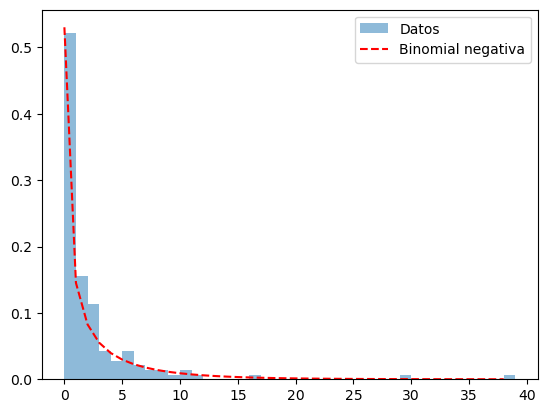

Chi2 = 131.08, p = 0.0000


In [36]:
datos = Todo_4326['Eventos']
media = np.mean(datos)
varianza = np.var(datos, ddof=1)

print(f"Media: {media}, Varianza: {varianza}")

# Histograma de tus datos
vals, freqs = np.unique(datos, return_counts=True)

# Función de verosimilitud negativa
def neg_log_likelihood(params):
    r, p = params
    if r <= 0 or not (0 < p < 1):
        return np.inf
    return -np.sum(nbinom.logpmf(datos, r, p))

res = opt.minimize(neg_log_likelihood, x0=[1, 0.5], bounds=[(1e-5, None), (1e-5, 1-1e-5)])
r_mle, p_mle = res.x
print(f"Parámetros ajustados: r = {r_mle:.3f}, p = {p_mle:.3f}")

x = np.arange(0, max(datos)+1)
fitted_pmf = nbinom.pmf(x, r_mle, p_mle)

plt.hist(datos, bins=range(max(datos)+2), density=True, alpha=0.5, label='Datos')
plt.plot(x, fitted_pmf, 'r--', label='Binomial negativa')
plt.legend()
plt.show()

expected_freqs = nbinom.pmf(vals, r_mle, p_mle)
 #Se tuvo que ajustar las escalas, porque la cola no alcanzaba todos los valores, lo que hacia que la probabilidad total fuera menor a 1
expected_freqs *= freqs.sum() / expected_freqs.sum() 
chi2, pval = chisquare(freqs, f_exp=expected_freqs)
print(f"Chi2 = {chi2:.2f}, p = {pval:.4f}")



### Ajuste Binomial Negativo

In [37]:
import statsmodels.api as sm
import statsmodels.discrete.discrete_model as smd
from sklearn.preprocessing import StandardScaler
Problema = Todo_4326.copy()

# Estandarizar variables
scaler = StandardScaler()
Problema = Todo_4326.copy()
Problema[["elevacion", "Ptotal","temp_max_prev_day",  "humidity_avg_prev_day",  "ndvi_2022" ]] = scaler.fit_transform(Problema[["elevacion", "Ptotal","temp_max_prev_day",  "humidity_avg_prev_day",  "ndvi_2022" ]])

# Variables predictoras y objetivo
X = sm.add_constant(Problema[["elevacion", "Ptotal","temp_max_prev_day",  "humidity_avg_prev_day",  "ndvi_2022" ]])
y = Problema["Eventos"]

# Modelo Binomial Negativo (alpha se estima automáticamente)
modelo_nb = smd.NegativeBinomial(y, X)
resultados_nb = modelo_nb.fit()  

# Resultados
print(resultados_nb.summary())

# Predicciones
Problema["mu_pred_nb"] = resultados_nb.predict()



Optimization terminated successfully.
         Current function value: 1.236045
         Iterations: 20
         Function evaluations: 21
         Gradient evaluations: 21
                     NegativeBinomial Regression Results                      
Dep. Variable:                Eventos   No. Observations:                  142
Model:               NegativeBinomial   Df Residuals:                      136
Method:                           MLE   Df Model:                            5
Date:                Sat, 21 Jun 2025   Pseudo R-squ.:                  0.3012
Time:                        19:26:57   Log-Likelihood:                -175.52
converged:                       True   LL-Null:                       -251.18
Covariance Type:            nonrobust   LLR p-value:                 6.981e-31
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const           

In [38]:
import statsmodels.api as sm
import statsmodels.discrete.discrete_model as smd

Problema = Todo_4326.copy()

# Estandarizar variables
scaler = StandardScaler()
Problema = Todo_4326.copy()
Problema[["elevacion", "Ptotal"]] = scaler.fit_transform(Problema[["elevacion", "Ptotal" ]])

# Variables predictoras y objetivo
X = sm.add_constant(Problema[["elevacion", "Ptotal"]])
y = Problema["Eventos"]

# Modelo Binomial Negativo (alpha se estima automáticamente)
modelo_nb = smd.NegativeBinomial(y, X)
resultados_nb = modelo_nb.fit()  

# Resultados
print(resultados_nb.summary())

# Predicciones
Problema["mu_pred_nb"] = resultados_nb.predict()

Optimization terminated successfully.
         Current function value: 1.238926
         Iterations: 13
         Function evaluations: 14
         Gradient evaluations: 14
                     NegativeBinomial Regression Results                      
Dep. Variable:                Eventos   No. Observations:                  142
Model:               NegativeBinomial   Df Residuals:                      139
Method:                           MLE   Df Model:                            2
Date:                Sat, 21 Jun 2025   Pseudo R-squ.:                  0.2996
Time:                        19:26:58   Log-Likelihood:                -175.93
converged:                       True   LL-Null:                       -251.18
Covariance Type:            nonrobust   LLR p-value:                 2.081e-33
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3694      0.135     -

Media: 2.04, Varianza: 21.58
Razón varianza/media: 10.60


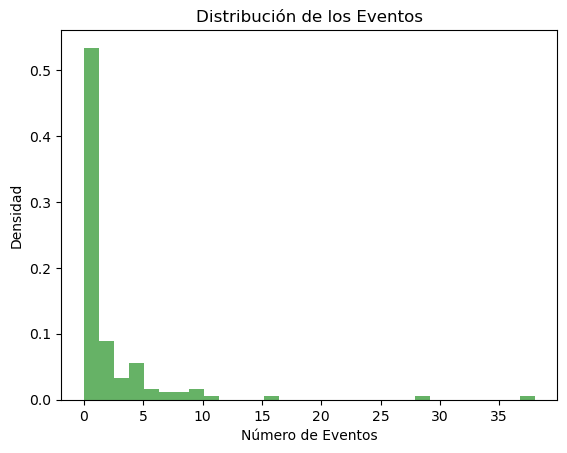

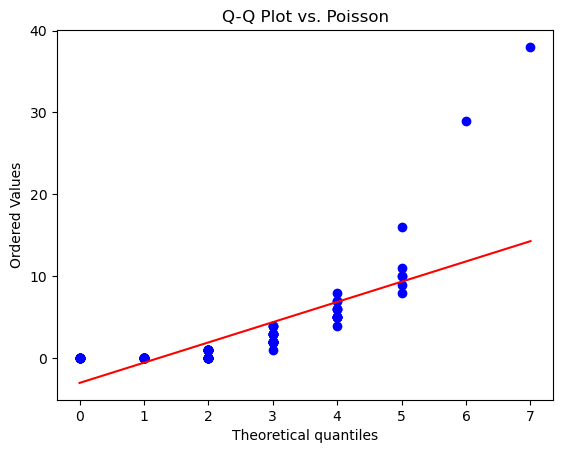

KS Test - p-valor: 0.0000
Chi-cuadrado - p-valor: 0.0000


In [39]:

media = np.mean(Todo_4326["Eventos"])
varianza = np.var(Todo_4326["Eventos"], ddof=1)  # ddof=1 para varianza muestral

print(f"Media: {media:.2f}, Varianza: {varianza:.2f}")
print(f"Razón varianza/media: {varianza/media:.2f}")  # Si ≈1, Poisson es viable

import matplotlib.pyplot as plt
import scipy.stats as stats

# Histograma
plt.hist(Todo_4326["Eventos"], bins=30, density=True, alpha=0.6, color='g')
plt.title("Distribución de los Eventos")
plt.xlabel("Número de Eventos")
plt.ylabel("Densidad")
plt.show()

# Gráfico Q-Q (Poisson)
stats.probplot(Todo_4326["Eventos"], dist="poisson", sparams=(media,), plot=plt)
plt.title("Q-Q Plot vs. Poisson")
plt.show()

from scipy.stats import kstest, chisquare

# Test de Kolmogorov-Smirnov (para distribuciones discretas)
ks_stat, p_valor = kstest(
    Todo_4326["Eventos"], 
    lambda x: stats.poisson.cdf(x, mu=media)
)
print(f"KS Test - p-valor: {p_valor:.4f}")  # p > 0.05 sugiere ajuste a Poisson

# Test Chi-cuadrado (requiere binned data)
frec_obs = np.bincount(Todo_4326["Eventos"])
frec_esp = stats.poisson.pmf(np.arange(len(frec_obs)), mu=media) * len(Todo_4326["Eventos"])
chi_stat, chi_p = chisquare(f_obs=frec_obs, f_exp=frec_esp)
print(f"Chi-cuadrado - p-valor: {chi_p:.4f}")  # p > 0.05 sugiere ajuste


In [40]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.discrete.discrete_model as smd

Problema = Todo_4326.copy()

# Variables predictoras
X = Problema[[ "elevacion", "Ptotal","temp_max_prev_day",  "humidity_avg_prev_day",  "ndvi_2022" ]]



# Añadir constante para el intercepto
X = sm.add_constant(X)

# Variable objetivo
y = Problema["Eventos"]

# Ajuste del modelo Poisson
modelo_pois = smd.Poisson(y, X)
resultados_pois = modelo_pois.fit()

# Resultados
print(resultados_pois.summary())

# Predicción
Problema["mu_pred_poisson"] = resultados_pois.predict()


Optimization terminated successfully.
         Current function value: 1.270252
         Iterations 13
                          Poisson Regression Results                          
Dep. Variable:                Eventos   No. Observations:                  142
Model:                        Poisson   Df Residuals:                      136
Method:                           MLE   Df Model:                            5
Date:                Sat, 21 Jun 2025   Pseudo R-squ.:                  0.6165
Time:                        19:26:58   Log-Likelihood:                -180.38
converged:                       True   LL-Null:                       -470.32
Covariance Type:            nonrobust   LLR p-value:                4.467e-123
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.2784      1.308     -0.213      0.831      -2.843       2

In [41]:

Problema = Todo_4326.copy()

# Variables predictoras
X = Problema[[ "elevacion", "Ptotal" ]]



# Añadir constante para el intercepto
X = sm.add_constant(X)

# Variable objetivo
y = Problema["Eventos"]

# Ajuste del modelo Poisson
modelo_pois = smd.Poisson(y, X)
resultados_pois = modelo_pois.fit()

# Resultados
print(resultados_pois.summary())

# Predicción
Problema["mu_pred_poisson"] = resultados_pois.predict()

Optimization terminated successfully.
         Current function value: 1.275139
         Iterations 13
                          Poisson Regression Results                          
Dep. Variable:                Eventos   No. Observations:                  142
Model:                        Poisson   Df Residuals:                      139
Method:                           MLE   Df Model:                            2
Date:                Sat, 21 Jun 2025   Pseudo R-squ.:                  0.6150
Time:                        19:26:58   Log-Likelihood:                -181.07
converged:                       True   LL-Null:                       -470.32
Covariance Type:            nonrobust   LLR p-value:                2.395e-126
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0218      0.133     -0.164      0.870      -0.283       0.239
elevacion     -0.0012      0

In [42]:
print(Todo_4326[["Eventos"]].describe())

          Eventos
count  142.000000
mean     2.035211
std      4.645461
min      0.000000
25%      0.000000
50%      0.000000
75%      2.000000
max     38.000000


In [43]:
np.var(Todo_4326["Eventos"])

21.428337631422377

In [44]:
np.mean(Todo_4326["Eventos"])

2.035211267605634